In [9]:
from util.test_load_data_from_db import load_data_from_db

df = load_data_from_db()

In [10]:
from mlxtend.feature_selection import SequentialFeatureSelector

from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from mlxtend.feature_selection import SequentialFeatureSelector
import numpy as np

# Загрузка данных Iris
iris = load_iris()
X = iris.data
y = iris.target

# Создание классификатора KNN
knn = KNeighborsClassifier(n_neighbors=4)

# Инициализация Sequential Backward Selection (SBS)
sbs = SequentialFeatureSelector(
    knn,
    k_features=2,
    forward=False,
    floating=False,
    scoring="accuracy",
    cv=2,
    n_jobs=-1,
)

# Запуск метода Sequential Backward Selection (SBS) для отбора признаков
sbs = sbs.fit(X, y)

# Индексы отобранных признаков
selected_feature_indices = sbs.k_feature_idx_

# Отобранные признаки
selected_features_sbs = X[:, sbs.k_feature_idx_]

# Получим названия отобранных признаков и напечатаем их
selected_features_names = np.array(iris.feature_names)[
    list(selected_feature_indices)
]
print("Отобранные признаки:", selected_features_names)

Отобранные признаки: ['petal length (cm)' 'petal width (cm)']


In [11]:
# Импорт необходимых библиотек
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector

# Чтение датасета
df = pd.read_csv("/datasets/housing.csv")

# Отделение признаков и целевой переменной
X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]

# Кодирование категориальной колонки 'ocean_proximity'
X = pd.get_dummies(X, columns=["ocean_proximity"], drop_first=True)

# Преобразуем X в numpy массив для совместимости с mlxtend
X = X.values
y = y.values

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Инициализация Sequential Feature Selector для backward selection
sbs = SequentialFeatureSelector(
    LinearRegression(),
    k_features=6,
    forward=False,
    floating=False,
    scoring="neg_mean_squared_error",
    cv=2,
    n_jobs=-1,
)
# Обучение SBS на обучающем наборе
sbs = sbs.fit(X_train, y_train)

# Выбор признаков с помощью SBS
selected_features_sbs = sbs.k_feature_idx_

# Инициализация Sequential Feature Selector с включённым параметром floating для SBFS
sbfs = SequentialFeatureSelector(
    LinearRegression(),
    k_features=6,
    forward=False,
    floating=True,
    scoring="neg_mean_squared_error",
    cv=2,
    n_jobs=-1,
)
# Обучение SBFS на обучающем наборе
sbfs = sbfs.fit(X_train, y_train)

# Выбор признаков с помощью SBFS
selected_features_sbfs = sbfs.k_feature_idx_

# Объединение индексов выбранных признаков из SBS и SBFS для обучения
selected_features = list(
    set(selected_features_sbs) | set(selected_features_sbfs)
)
X_train_selected = X_train[:, selected_features]
X_test_selected = X_test[:, selected_features]

# Обучение модели линейной регрессии на выбранных признаках
model = LinearRegression()
model.fit(X_train_selected, y_train)

FileNotFoundError: [Errno 2] No such file or directory: '/datasets/housing.csv'

In [ ]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

iris_df = load_iris()
X = iris_df.data
y = iris_df.target

knn = KNeighborsClassifier(n_neighbors=3)

sfs = SFS(
    knn,
    k_features=4,
    forward=True,
    floating=False,
    scoring="accuracy",
    verbose=2,
    cv=5,
)

sfs = sfs.fit(X, y)

fig1 = plot_sfs(sfs.get_metric_dict(), kind="std_dev")

plt.ylim([0.8, 1])
plt.title("Sequential Forward Selection (w. StdDev)")
plt.grid()
plt.show()

In [ ]:
import os

import psycopg
import pandas as pd
import mlflow
from catboost import CatBoostClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

TABLE_NAME = # ваш код здесь #
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5003

EXPERIMENT_NAME = "EXP_remove"# ваш код здесь #
RUN_NAME = "feature_selection_remove"
REGISTRY_MODEL_NAME = "selection_model_remove"# ваш код здесь #
FS_ASSETS = "fs_assets"



In [ ]:
import os
import pandas as pd
import mlflow
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.neighbors import KNeighborsClassifier

estimator = KNeighborsClassifier(n_neighbors=3)

os.environ["MLFLOW_S3_ENDPOINT_URL"] = os.getenv("MLFLOW_S3_ENDPOINT_URL")
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

os.environ["MLFLOW_S3_ENDPOINT_URL"] = os.getenv("MLFLOW_S3_ENDPOINT_URL")
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")

storage_options = {
    "key": os.getenv("AWS_ACCESS_KEY_ID"),
    "secret": os.getenv("AWS_SECRET_ACCESS_KEY"),
    # Если используете не AWS, а стороннее S3-хранилище (Yandex Cloud и т.д.):
    "client_kwargs": {"endpoint_url": "https://storage.yandexcloud.net"},
}
csv_path = "s3://s3-student-mle-20260614-fb07c65e05/15/5f31a4f5dad64c75bc03b007bab3614d/artifacts/models/extended_data.csv"

df_new = pd.read_csv(csv_path, storage_options=storage_options)
pipeline = mlflow.sklearn.load_model(
    "s3://s3-student-mle-20260614-fb07c65e05/15/5f31a4f5dad64c75bc03b007bab3614d/artifacts/models"
)
preprocessor = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]

X = (
    df_new.drop(columns=["target"])
    .select_dtypes(include="number")
    .drop(columns=["id"], errors="ignore")
)
print(X.shape)

y = df_new["target"]

sfs = SFS(
    estimator,
    k_features=10,
    forward=True,
    floating=False,
    scoring="roc_auc",
    verbose=2,
    cv=4,
)
sbs = SFS(
    estimator,
    k_features=10,
    forward=False,
    floating=False,
    scoring="roc_auc",
    verbose=2,
    cv=4,
)

sfs = sfs.fit(X, y)
sbs = sbs.fit(X, y)

top_sfs = sfs.k_feature_names_
top_sbs = sbs.k_feature_names_

print("\nSequential Forward Selection (k=10)")
print("CV Score:")
print(sfs.k_score_)

print("\nSequential Backward Selection")
print("CV Score:")
print(sbs.k_score_)

interc_features = list(set(top_sbs) & set(top_sfs))
union_features = list(set(top_sbs) | set(top_sfs))

(7043, 36)


[Parallel(n_jobs=1)]: Done  36 out of  36 | elapsed:    0.9s finished

[2026-07-21 03:32:20] Features: 1/10 -- score: 0.6076315756261023[Parallel(n_jobs=1)]: Done  35 out of  35 | elapsed:    0.5s finished

[2026-07-21 03:32:21] Features: 2/10 -- score: 0.6373179166950047[Parallel(n_jobs=1)]: Done  34 out of  34 | elapsed:    0.6s finished

[2026-07-21 03:32:22] Features: 3/10 -- score: 0.6552495074842737[Parallel(n_jobs=1)]: Done  33 out of  33 | elapsed:    0.5s finished

[2026-07-21 03:32:22] Features: 4/10 -- score: 0.6750366337334583[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:    0.7s finished

[2026-07-21 03:32:23] Features: 5/10 -- score: 0.6962031357506487[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    0.8s finished

[2026-07-21 03:32:24] Features: 6/10 -- score: 0.7067247142402721[Parallel(n_jobs=1)]: Done  30 out of  30 | elapsed:    0.9s finished

[2026-07-21 03:32:25] Features: 7/10 -- score: 0.7147278197983267[Parallel(n_jobs=1)]: Done  29 out of  29 | elap


Sequential Forward Selection (k=10)
CV Score:
0.7160152690981437

Sequential Backward Selection
CV Score:
0.6137495864095227


[Parallel(n_jobs=1)]: Done  12 out of  12 | elapsed:    0.2s finished

[2026-07-21 03:32:42] Features: 11/10 -- score: 0.6136365809468709[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:    0.2s finished

[2026-07-21 03:32:42] Features: 10/10 -- score: 0.6137495864095227

In [28]:
import os

FS_ASSETS = "fs_assets"

sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T

os.mkdir(FS_ASSETS)

sfs_df.to_csv(f"{FS_ASSETS}/sfs.csv")
sbs_df.to_csv(f"{FS_ASSETS}/sbs.csv")

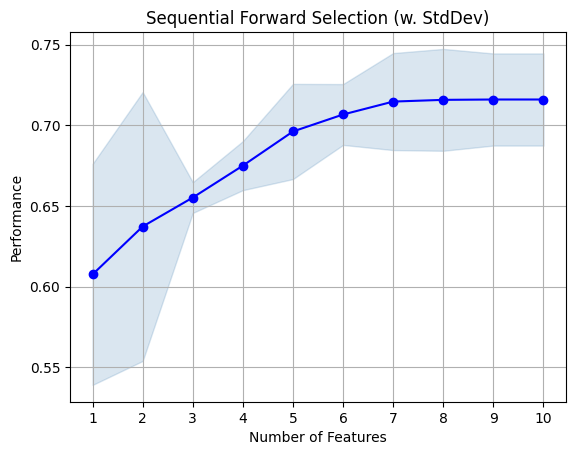

<Figure size 640x480 with 0 Axes>

In [29]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind="std_dev")

plt.title("Sequential Forward Selection (w. StdDev)")
plt.grid()
plt.show()

plt.savefig("FS_ASSETS/sfs.png")

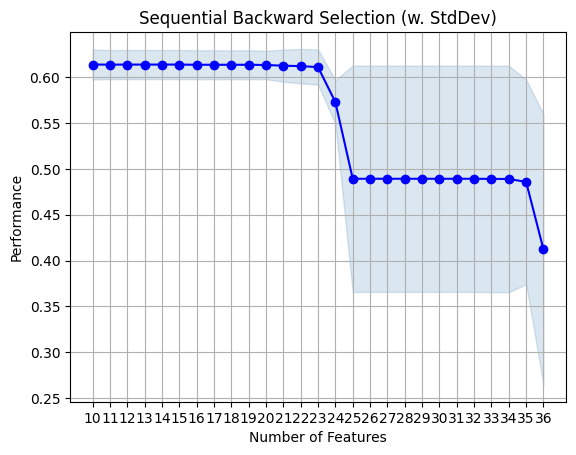

<Figure size 640x480 with 0 Axes>

In [30]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sbs.get_metric_dict(), kind="std_dev")

plt.title("Sequential Backward Selection (w. StdDev)")
plt.grid()
plt.show()

plt.savefig("FS_ASSETS/sbs.png")

In [ ]:
estimator = RandomForestClassifier(n_estimators=300)

sfs = SFS(
    estimator,
    k_features=10,
    forward=True,
    floating=False,
    scoring="roc_auc",
    cv=4,
    n_jobs=-1,
)
sbs = SFS(
    estimator,
    k_features=10,
    forward=False,
    floating=False,
    scoring="roc_auc",
    cv=4,
    n_jobs=-1,
)

sfs = sfs.fit(X_train_features, y_train)
sbs = sbs.fit(X_train_features, y_train)

top_sfs = sfs.k_feature_names_  # ваш код здесь #
top_sbs = sbs.k_feature_names_  # ваш код здесь #

print("\nSequential Forward Selection (k=10)")
print("CV Score:")
print(sfs.k_score_)

print("\nSequential Backward Selection")
print("CV Score:")
print(sbs.k_score_)

sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T

In [ ]:
# добавь импорты все
import os
import mlflow
import mlflow.sklearn


def log_afc_model2():
    TRACKING_SERVER_HOST = "127.0.0.1"
    TRACKING_SERVER_PORT = 5003
    TRACKING_SERVER_URL = (
        f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}"
    )
    EXPERIMENT_NAME = "remove_cols_experiment"
    RUN_NAME = "remove_cols_run_1"

    mlflow.set_tracking_uri(TRACKING_SERVER_URL)
    mlflow.set_registry_uri(TRACKING_SERVER_URL)

    experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
    if not experiment_id:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
        experiment_id = mlflow.get_experiment_by_name(
            EXPERIMENT_NAME
        ).experiment_id

    with mlflow.start_run(
        run_name=RUN_NAME, experiment_id=experiment_id
    ) as run:
        run_id = run.info.run_id
        mlflow.log_artifacts(FS_ASSETS)


log_afc_model1()

🏃 View run remove_cols_run_1 at: http://127.0.0.1:5003/#/experiments/16/runs/15e184f8d88743848319a8c830f1b175
🧪 View experiment at: http://127.0.0.1:5003/#/experiments/16


In [ ]:
interc_features = list(set(top_sbs) & set(top_sfs))
union_features = list(set(top_sbs) | set(top_sfs))

print("Общие признаки:", interc_features)
print("Объединение признаков:", union_features)
print("sbs:", sbs)
print("sfs:", sfs)

In [ ]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split

target_col = "target"

X_train, X_val = train_test_split(
    df_new,
    test_size=0.2,
    random_state=42,
    stratify=df_new[target_col],
)

y_train = X_train[target_col]
y_val = X_val[target_col]

X_train = X_train.drop(columns=[target_col])
X_val = X_val.drop(columns=[target_col])

# Фильтруем датафреймы по отобранным именам признаков:
X_train_sfs = X_train[list(top_sfs)]
X_train_sbs = X_train[list(top_sbs)]

ValueError: A given column is not a column of the dataframe

In [ ]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

# Для выбранных признаков обучаем только модель, без исходного preprocessor.
X_val_sfs = X_val[list(top_sfs)]
X_val_sbs = X_val[list(top_sbs)]

model_sfs = clone(model)
model_sbs = clone(model)

model_sfs.fit(X_train_sfs, y_train)
model_sbs.fit(X_train_sbs, y_train)

sfs_roc_auc = roc_auc_score(y_val, model_sfs.predict_proba(X_val_sfs)[:, 1])
sbs_roc_auc = roc_auc_score(y_val, model_sbs.predict_proba(X_val_sbs)[:, 1])

print(f"SFS ROC-AUC: {sfs_roc_auc:.4f}")
print(f"SBS ROC-AUC: {sbs_roc_auc:.4f}")

Learning rate set to 0.021554
0:	learn: 0.6834695	total: 57.9ms	remaining: 57.8s
1:	learn: 0.6739990	total: 59.1ms	remaining: 29.5s
2:	learn: 0.6652446	total: 60.1ms	remaining: 20s
3:	learn: 0.6596381	total: 60.8ms	remaining: 15.1s
4:	learn: 0.6520426	total: 61.8ms	remaining: 12.3s
5:	learn: 0.6440012	total: 62.8ms	remaining: 10.4s
6:	learn: 0.6377213	total: 63.9ms	remaining: 9.06s
7:	learn: 0.6317790	total: 64.9ms	remaining: 8.04s
8:	learn: 0.6252283	total: 65.9ms	remaining: 7.26s
9:	learn: 0.6191124	total: 66.8ms	remaining: 6.62s
10:	learn: 0.6140584	total: 67.7ms	remaining: 6.09s
11:	learn: 0.6084298	total: 68.8ms	remaining: 5.67s
12:	learn: 0.6037263	total: 69.9ms	remaining: 5.3s
13:	learn: 0.5987923	total: 71ms	remaining: 5s
14:	learn: 0.5939376	total: 71.9ms	remaining: 4.72s
15:	learn: 0.5892171	total: 73ms	remaining: 4.49s
16:	learn: 0.5850091	total: 74.3ms	remaining: 4.29s
17:	learn: 0.5803727	total: 75.3ms	remaining: 4.11s
18:	learn: 0.5768341	total: 76.3ms	remaining: 3.94s
19

In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

TRACKING_SERVER_URL = "http://127.0.0.1:5003"
REGISTERED_MODEL_NAME = "sfs_sbs_model"

mlflow.set_tracking_uri(TRACKING_SERVER_URL)
mlflow.set_registry_uri(TRACKING_SERVER_URL)


def get_or_create_experiment_id(experiment_name):
    experiment = mlflow.get_experiment_by_name(experiment_name)
    if experiment is None:
        return mlflow.create_experiment(experiment_name)
    return experiment.experiment_id


def log_selected_model(
    *,
    experiment_name,
    run_name,
    trained_model,
    X_train_selected,
    selected_features,
    roc_auc,
):
    experiment_id = get_or_create_experiment_id(experiment_name)
    signature = infer_signature(
        X_train_selected,
        trained_model.predict(X_train_selected),
    )

    with mlflow.start_run(
        run_name=run_name, experiment_id=experiment_id
    ) as run:
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_dict(
            {"selected_features": list(selected_features)},
            "selected_features.json",
        )

        model_info = mlflow.sklearn.log_model(
            sk_model=trained_model,
            artifact_path="model",
            registered_model_name=REGISTERED_MODEL_NAME,
            signature=signature,
            input_example=X_train_selected.head(5),
            serialization_format=(
                mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE
            ),
        )

        print(f"Experiment: {experiment_name}")
        print(f"Run ID: {run.info.run_id}")
        print(f"Model URI: {model_info.model_uri}")
        return run.info.run_id, model_info.model_uri


sfs_run_id, sfs_model_uri = log_selected_model(
    experiment_name="remove_cols_sfs_experiment",
    run_name="sfs_selected_features",
    trained_model=model_sfs,
    X_train_selected=X_train_sfs,
    selected_features=top_sfs,
    roc_auc=sfs_roc_auc,
)

sbs_run_id, sbs_model_uri = log_selected_model(
    experiment_name="remove_cols_sbs_experiment",
    run_name="sbs_selected_features",
    trained_model=model_sbs,
    X_train_selected=X_train_sbs,
    selected_features=top_sbs,
    roc_auc=sbs_roc_auc,
)